# Agentic causal-analysis assistant — LangGraph

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jmdvinodjmd/agentic-ai-tutorial/blob/main/notebooks/case_studies/independent/causal_analysis/langgraph.ipynb)

This notebook demonstrates a controlled causal-analysis pipeline on the UCI **Diabetes 130-US Hospitals (1999–2008)** dataset:

`load_data → define_problem → discover_structure → review_structure → identify → estimate_ate → estimate_cate → diagnose → sensitivity → report`

The treatment is whether diabetes medication was changed during the encounter (`change == "Ch"`); the outcome is readmission within 30 days. This is an **exploratory tutorial**, not a clinical effectiveness study: treatment is observational, the dataset was designed for prediction, and important confounders may be absent.

Dataset: Clore et al. (2014), UCI Machine Learning Repository, DOI: 10.24432/C5230J.

This is the single implementation of Case Study 4; it is intentionally not repeated across every framework. It reuses the repository's existing model interface, while its causal-analysis dependencies and logic remain local to this notebook. A run on 4,000 rows can take several minutes on CPU, mainly because of causal discovery, the causal forest and repeated sensitivity fits.


In [ ]:
# --- User configuration ---
MODEL_PROVIDER = "mock"  # mock | local | api
MOCK_MODEL_NAME = "causal-review-v1"
LOCAL_MODEL_NAME = "Qwen3-0.6B-Q8_0"
API_MODEL_NAME = "gemini-3.1-flash-lite"
LOCAL_MODEL_PATH = "models/local/Qwen3-0.6B-Q8_0.gguf"
SAVE_API_CREDENTIAL = False
RANDOM_SEED = 7
MAX_ROWS = 4000
DISCOVERY_ALPHA = 0.01
INSTALL_CAUSAL_DEPENDENCIES = True
if MODEL_PROVIDER not in {"mock", "local", "api"}:
    raise ValueError("MODEL_PROVIDER must be mock, local or api")
CAUSAL_QUESTION = (
    "What is the effect of changing diabetes medication during the encounter "
    "on readmission within 30 days, and how does the estimated effect vary across patients?"
)


In [12]:
# Bootstrap only this independent case study; do not modify the shared lockfile.
import importlib.util
import shutil
import subprocess
import sys
from pathlib import Path

CAUSAL_PACKAGES = [
    "dowhy[plotting,econml]==0.14",
    "langgraph==1.2.9",
    "ucimlrepo==0.0.7",
]
required_modules = (
    "dowhy", "econml", "causallearn", "langgraph", "matplotlib", "ucimlrepo"
)
missing_dependencies = [
    name for name in required_modules if importlib.util.find_spec(name) is None
]
if INSTALL_CAUSAL_DEPENDENCIES and missing_dependencies:
    if importlib.util.find_spec("pip") is not None:
        install_command = [sys.executable, "-m", "pip", "install", "-q", *CAUSAL_PACKAGES]
    elif shutil.which("uv"):
        install_command = [
            "uv", "pip", "install", "--python", sys.executable, *CAUSAL_PACKAGES
        ]
    else:
        raise RuntimeError("Neither pip nor uv is available to install causal dependencies.")
    subprocess.run(install_command, check=True)

# A fresh Colab runtime contains the notebook but not the repository source package.
if "google.colab" in sys.modules:
    colab_root = Path("/content/agentic-ai-tutorial")
    if not (colab_root / "pyproject.toml").exists():
        subprocess.run(
            [
                "git", "clone", "--depth", "1", "--branch", "main",
                "https://github.com/jmdvinodjmd/agentic-ai-tutorial.git",
                str(colab_root),
            ],
            check=True,
        )


In [13]:
import json
import sys
import warnings
from pathlib import Path
from typing import Any, Literal, TypedDict
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from pydantic import BaseModel, ConfigDict, Field
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from langgraph.graph import END, START, StateGraph
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path("/content/agentic-ai-tutorial") if "google.colab" in sys.modules else Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
USING_REPOSITORY = (ROOT / "pyproject.toml").exists()
if USING_REPOSITORY:
    sys.path.insert(0, str(ROOT / "src"))
    from agentic_tutorial.models import GenerationSettings, create_model
    from agentic_tutorial.notebook import prepare_gemini_api_key
    from agentic_tutorial.schemas import Message, MessageRole
    if MODEL_PROVIDER == "api":
        prepare_gemini_api_key(ROOT, save=SAVE_API_CREDENTIAL)
else:
    raise RuntimeError("Run from the repository or use the Open in Colab badge.")



## Controlled use of the LLM

Causal discovery proposes adjacencies. The LLM may only review and orient those candidates under fixed temporal constraints. Deterministic code rejects cycles, post-treatment adjustment variables and inadmissible directions. The LLM never executes estimators or changes numeric results. The DoWhy model uses the prespecified baseline adjustment set shown below; it does not treat the LLM-reviewed graph as proof of identification.


In [14]:

class Strict(BaseModel):
    model_config=ConfigDict(extra='forbid')
class ReviewedEdge(Strict):
    source:str; target:str; decision:Literal['accept','reject']; rationale:str=Field(min_length=3,max_length=240)
class DomainReview(Strict):
    edges:tuple[ReviewedEdge,...]; adjustment_set:tuple[str,...]; cautions:tuple[str,...]
class State(TypedDict,total=False):
    question:str; raw_data:pd.DataFrame; analysis_data:pd.DataFrame; treatment:str; outcome:str
    candidate_edges:list[tuple[str,str]]; reviewed_edges:list[tuple[str,str]]; adjustment_set:list[str]
    discovery_graph:nx.Graph; reviewed_dag:nx.DiGraph; dowhy_model:Any; estimand:Any; ate_estimate:Any
    ate_value:float; cate_model:Any; cate:np.ndarray; propensity:np.ndarray; refutations:dict[str,float]
    sensitivity_line:Any; sensitivity_grid:Any
    diagnostics:dict[str,Any]; cautions:list[str]; trace:list[dict[str,Any]]; termination:str
VARIABLES={
 'age_band':'Age band at admission','female':'Recorded gender indicator','race_group':'Broad recorded race category',
 'admission_type':'Admission type','admission_source':'Admission source','prior_outpatient':'Prior outpatient visits',
 'prior_emergency':'Prior emergency visits','prior_inpatient':'Prior inpatient visits','diagnosis_count':'Recorded diagnosis count',
 'medication_change':'Treatment: diabetes medication changed','readmitted_30d':'Outcome: readmission within 30 days'}
TIERS={0:{'age_band','female','race_group','admission_type','admission_source','prior_outpatient','prior_emergency','prior_inpatient','diagnosis_count'},1:{'medication_change'},2:{'readmitted_30d'}}
TIER_OF={n:t for t,ns in TIERS.items() for n in ns}
TREATMENT='medication_change'; OUTCOME='readmitted_30d'; BASELINE=sorted(TIERS[0])
def user_message(text): return Message(role=MessageRole.USER, content=text)
def review_model():
    if MODEL_PROVIDER=='mock': return None
    if not USING_REPOSITORY: raise RuntimeError('Run inside the cloned repository for local/api providers.')
    names={'mock':MOCK_MODEL_NAME,'local':LOCAL_MODEL_NAME,'api':API_MODEL_NAME}
    p=Path(LOCAL_MODEL_PATH); p=p if p.is_absolute() else ROOT/p
    return create_model(provider=MODEL_PROVIDER, model=names[MODEL_PROVIDER],
        model_path=p if MODEL_PROVIDER=='local' else None,
        metadata_path=ROOT/'models/local/model_metadata.json',
        settings=GenerationSettings(temperature=0.0,max_output_tokens=2048,seed=RANDOM_SEED),
        options={'timeout_seconds':240.0})
def mock_review(edges):
    accepted=[]
    for a,b in edges:
        if TIER_OF[a]<TIER_OF[b]: s,t=a,b
        elif TIER_OF[b]<TIER_OF[a]: s,t=b,a
        else: continue
        accepted.append(ReviewedEdge(source=s,target=t,decision='accept',rationale='Temporal-tier orientation.'))
    for s,t in [('age_band',TREATMENT),('prior_inpatient',TREATMENT),('age_band',OUTCOME),('prior_inpatient',OUTCOME),(TREATMENT,OUTCOME)]:
        if not any(e.source==s and e.target==t for e in accepted):
            accepted.append(ReviewedEdge(source=s,target=t,decision='accept',rationale='Transparent tutorial domain assumption.'))
    return DomainReview(edges=tuple(accepted), adjustment_set=tuple(BASELINE), cautions=(
        'The dataset was not designed to identify this treatment effect.',
        'Medication change is a broad care-process indicator rather than a specific treatment.',
        'Unmeasured severity and clinician judgement may confound the estimate.'))
async def llm_review(edges):
    if MODEL_PROVIDER=='mock': return mock_review(edges)
    model=review_model()
    prompt=(f"Review this exploratory causal structure.\nQuestion: {CAUSAL_QUESTION}\n" f"Variables: {json.dumps(VARIABLES)}\nTemporal tiers: {TIERS}\n" f"Candidate adjacencies: {json.dumps(edges)}\n" "Rules: review only listed adjacencies; orient earlier to later tiers; adjustment variables must be tier 0; state limitations.")
    r=await model.generate([user_message(prompt)],response_schema=DomainReview)
    return DomainReview.model_validate(r.structured_output)


In [15]:

from ucimlrepo import fetch_ucirepo

def load_data(max_rows=MAX_ROWS):
    ds=fetch_ucirepo(id=296)
    df=pd.concat([ds.data.features.copy(),ds.data.targets.copy()],axis=1)
    return df.sample(min(len(df),max_rows),random_state=RANDOM_SEED).reset_index(drop=True)

def prepare_data(df):
    req=['age','gender','race','admission_type_id','admission_source_id','number_outpatient','number_emergency','number_inpatient','number_diagnoses','change','readmitted']
    miss=sorted(set(req)-set(df.columns))
    if miss: raise ValueError(f'Missing columns: {miss}')
    age={f'[{i}-{i+10})':i//10 for i in range(0,100,10)}
    out=pd.DataFrame(index=df.index)
    out['age_band']=df['age'].map(age)
    out['female']=df['gender'].map({'Female':1,'Male':0})
    out['race_group']=df['race'].replace('?',np.nan).fillna('Unknown').astype('category').cat.codes
    out['admission_type']=pd.to_numeric(df['admission_type_id'],errors='coerce')
    out['admission_source']=pd.to_numeric(df['admission_source_id'],errors='coerce')
    out['prior_outpatient']=pd.to_numeric(df['number_outpatient'],errors='coerce')
    out['prior_emergency']=pd.to_numeric(df['number_emergency'],errors='coerce')
    out['prior_inpatient']=pd.to_numeric(df['number_inpatient'],errors='coerce')
    out['diagnosis_count']=pd.to_numeric(df['number_diagnoses'],errors='coerce')
    out[TREATMENT]=(df['change']=='Ch').astype(int)
    out[OUTCOME]=(df['readmitted']=='<30').astype(int)
    out=out.dropna().astype(int).reset_index(drop=True)
    if out[TREATMENT].nunique()!=2 or out[OUTCOME].nunique()!=2: raise ValueError('Degenerate treatment or outcome.')
    return out

def discover(data):
    from causallearn.search.ConstraintBased.PC import pc
    cols=list(data.columns); m=data[cols].to_numpy(dtype=int)
    try: r=pc(m,alpha=DISCOVERY_ALPHA,indep_test='chisq',stable=True,node_names=cols,show_progress=False)
    except TypeError: r=pc(m,DISCOVERY_ALPHA,'chisq',stable=True,node_names=cols,show_progress=False)
    g=np.asarray(r.G.graph); edges=[]
    for i in range(len(cols)):
        for j in range(i+1,len(cols)):
            if g[i,j]!=0 or g[j,i]!=0: edges.append((cols[i],cols[j]))
    nxg=nx.Graph(); nxg.add_nodes_from(cols); nxg.add_edges_from(edges)
    return edges,nxg

def validate_review(review,candidates):
    cand={frozenset(e) for e in candidates}; accepted=[]
    for e in review.edges:
        if e.decision!='accept' or e.source not in TIER_OF or e.target not in TIER_OF: continue
        if TIER_OF[e.source]>=TIER_OF[e.target]: continue
        if MODEL_PROVIDER!='mock' and frozenset((e.source,e.target)) not in cand: continue
        accepted.append((e.source,e.target))
    if (TREATMENT,OUTCOME) not in accepted: accepted.append((TREATMENT,OUTCOME))
    adj=list(dict.fromkeys([x for x in review.adjustment_set if x in BASELINE]))
    dag=nx.DiGraph(); dag.add_nodes_from(VARIABLES); dag.add_edges_from(accepted)
    if not nx.is_directed_acyclic_graph(dag): raise ValueError('Reviewed graph is cyclic.')
    if not adj: raise ValueError('No valid baseline adjustment set.')
    return list(dict.fromkeys(accepted)),adj,dag

def dowhy_model(data,adj):
    from dowhy import CausalModel
    model=CausalModel(data=data,treatment=TREATMENT,outcome=OUTCOME,common_causes=adj,effect_modifiers=adj)
    estimand=model.identify_effect(proceed_when_unidentifiable=False)
    return model,estimand

def ate(model,estimand):
    est=model.estimate_effect(estimand,method_name='backdoor.propensity_score_weighting',target_units='ate',method_params={'weighting_scheme':'ips_weight','min_ps_score':0.05,'max_ps_score':0.95})
    return est,float(est.value)

def design(data,covs):
    cats=[c for c in ['race_group','admission_type','admission_source'] if c in covs]; nums=[c for c in covs if c not in cats]
    tr=ColumnTransformer([('num',StandardScaler(),nums),('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cats)])
    return tr.fit_transform(data[covs]),tr

def cate(data,covs):
    from econml.dml import CausalForestDML
    X,tr=design(data,covs); Y=data[OUTCOME].to_numpy(float); T=data[TREATMENT].to_numpy(int)
    est=CausalForestDML(model_y=RandomForestRegressor(n_estimators=150,min_samples_leaf=20,random_state=RANDOM_SEED,n_jobs=-1),model_t=RandomForestClassifier(n_estimators=150,min_samples_leaf=20,random_state=RANDOM_SEED,n_jobs=-1),discrete_treatment=True,n_estimators=300,min_samples_leaf=30,max_depth=12,cv=3,random_state=RANDOM_SEED,n_jobs=-1)
    est.fit(Y,T,X=X); return est,np.asarray(est.effect(X)).reshape(-1),tr

def propensity(data,covs):
    cats=[c for c in ['race_group','admission_type','admission_source'] if c in covs]; nums=[c for c in covs if c not in cats]
    pipe=Pipeline([('prep',ColumnTransformer([('num',StandardScaler(),nums),('cat',OneHotEncoder(handle_unknown='ignore'),cats)])),('model',LogisticRegression(max_iter=1500,random_state=RANDOM_SEED))])
    pipe.fit(data[covs],data[TREATMENT]); p=pipe.predict_proba(data[covs])[:,1]
    return p,float(roc_auc_score(data[TREATMENT],p))

def refute(model,estimand,estimate):
    specs={'random_common_cause':{'method_name':'random_common_cause','random_seed':RANDOM_SEED},'data_subset':{'method_name':'data_subset_refuter','subset_fraction':0.8,'num_simulations':10,'random_seed':RANDOM_SEED},'placebo_treatment':{'method_name':'placebo_treatment_refuter','placebo_type':'permute','num_simulations':10,'random_seed':RANDOM_SEED}}
    out={}
    for k,kw in specs.items():
        try: out[k]=float(model.refute_estimate(estimand,estimate,show_progress_bar=False,**kw).new_effect)
        except Exception as e: out[k]=np.nan; print(f'{k} unavailable: {e}')
    return out

def unobserved_confounder_sensitivity(model,estimand,estimate):
    """Run DoWhy's simulation refuter and let DoWhy render its native plots."""
    strengths=np.array([0.001,0.005,0.01,0.02,0.04,0.06])
    np.random.seed(RANDOM_SEED)
    line=model.refute_estimate(
        estimand,estimate,method_name='add_unobserved_common_cause',
        simulation_method='direct-simulation',
        confounders_effect_on_treatment='binary_flip',
        confounders_effect_on_outcome='linear',
        effect_strength_on_treatment=strengths,
        effect_strength_on_outcome=0.02,
        plotmethod='line',show_progress_bar=False)
    np.random.seed(RANDOM_SEED)
    grid=model.refute_estimate(
        estimand,estimate,method_name='add_unobserved_common_cause',
        simulation_method='direct-simulation',
        confounders_effect_on_treatment='binary_flip',
        confounders_effect_on_outcome='linear',
        effect_strength_on_treatment=strengths,
        effect_strength_on_outcome=strengths,
        plotmethod='colormesh',show_progress_bar=False)
    return line,grid


/Users/pfb25127/Library/CloudStorage/OneDrive-UniversityofStrathclyde/University of Strathclyde/Research/Papers/Agentic AI Tutorial/agentic-ai-tutorial/.venv/lib/python3.11/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


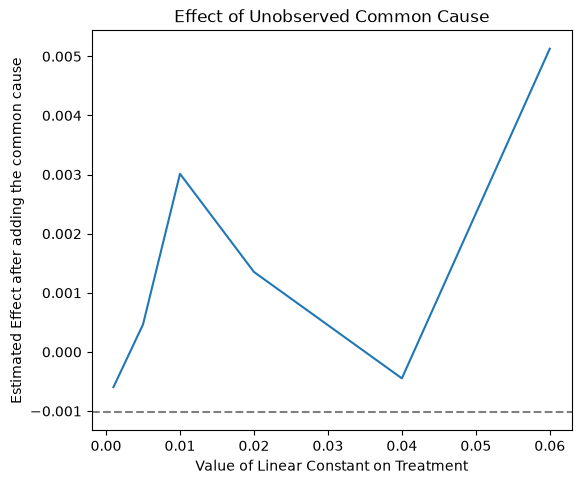

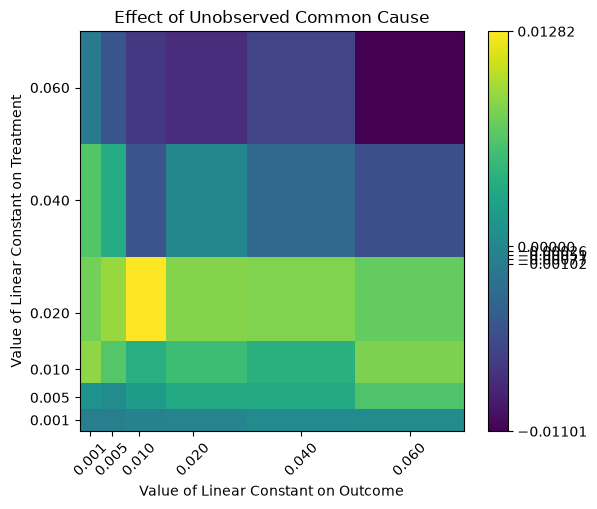

In [16]:

def load_node(s):
    raw=load_data(); return {**s,'raw_data':raw,'trace':[{'event':'load_data','rows':len(raw)}]}
def define_node(s):
    d=prepare_data(s['raw_data']); return {**s,'question':CAUSAL_QUESTION,'analysis_data':d,'treatment':TREATMENT,'outcome':OUTCOME,'trace':[*s['trace'],{'event':'define_problem','rows':len(d),'treated':int(d[TREATMENT].sum()),'outcomes':int(d[OUTCOME].sum())}]}
def discover_node(s):
    e,g=discover(s['analysis_data']); return {**s,'candidate_edges':e,'discovery_graph':g,'trace':[*s['trace'],{'event':'discover_structure','candidate_edges':len(e)}]}
async def review_node(s):
    r=await llm_review(s['candidate_edges']); e,a,d=validate_review(r,s['candidate_edges']); return {**s,'reviewed_edges':e,'adjustment_set':a,'reviewed_dag':d,'cautions':list(r.cautions),'trace':[*s['trace'],{'event':'review_structure','accepted_edges':len(e),'adjustment_set':a}]}
def identify_node(s):
    m,e=dowhy_model(s['analysis_data'],s['adjustment_set']); return {**s,'dowhy_model':m,'estimand':e,'trace':[*s['trace'],{'event':'identify'}]}
def ate_node(s):
    e,v=ate(s['dowhy_model'],s['estimand']); return {**s,'ate_estimate':e,'ate_value':v,'trace':[*s['trace'],{'event':'estimate_ate','ate':v}]}
def cate_node(s):
    m,c,tr=cate(s['analysis_data'],s['adjustment_set']); return {**s,'cate_model':m,'cate':c,'cate_transformer':tr,'trace':[*s['trace'],{'event':'estimate_cate','mean':float(c.mean()),'sd':float(c.std())}]}
def diagnose_node(s):
    p,auc=propensity(s['analysis_data'],s['adjustment_set']); overlap=float(np.mean((p>=0.05)&(p<=0.95))); d={'propensity_auc':auc,'overlap_fraction_0.05_0.95':overlap,'treated_fraction':float(s['analysis_data'][TREATMENT].mean()),'outcome_fraction':float(s['analysis_data'][OUTCOME].mean())}; return {**s,'propensity':p,'diagnostics':d,'trace':[*s['trace'],{'event':'diagnose',**d}]}
def sensitivity_node(s):
    r=refute(s['dowhy_model'],s['estimand'],s['ate_estimate'])
    line,grid=unobserved_confounder_sensitivity(s['dowhy_model'],s['estimand'],s['ate_estimate'])
    tests=[*r,'unobserved_common_cause_line','unobserved_common_cause_grid']
    return {**s,'refutations':r,'sensitivity_line':line,'sensitivity_grid':grid,'trace':[*s['trace'],{'event':'sensitivity','tests':tests}]}
def report_node(s):
    term='criteria_met' if s['diagnostics']['overlap_fraction_0.05_0.95']>=0.8 and np.isfinite(s['ate_value']) else 'qualified_result'; return {**s,'termination':term,'trace':[*s['trace'],{'event':'report','termination':term}]}

b=StateGraph(State)
for n,f in [('load_data',load_node),('define_problem',define_node),('discover_structure',discover_node),('review_structure',review_node),('identify',identify_node),('estimate_ate',ate_node),('estimate_cate',cate_node),('diagnose',diagnose_node),('sensitivity',sensitivity_node),('report',report_node)]: b.add_node(n,f)
for a,z in [(START,'load_data'),('load_data','define_problem'),('define_problem','discover_structure'),('discover_structure','review_structure'),('review_structure','identify'),('identify','estimate_ate'),('estimate_ate','estimate_cate'),('estimate_cate','diagnose'),('diagnose','sensitivity'),('sensitivity','report'),('report',END)]: b.add_edge(a,z)
workflow=b.compile(); result=await workflow.ainvoke({})


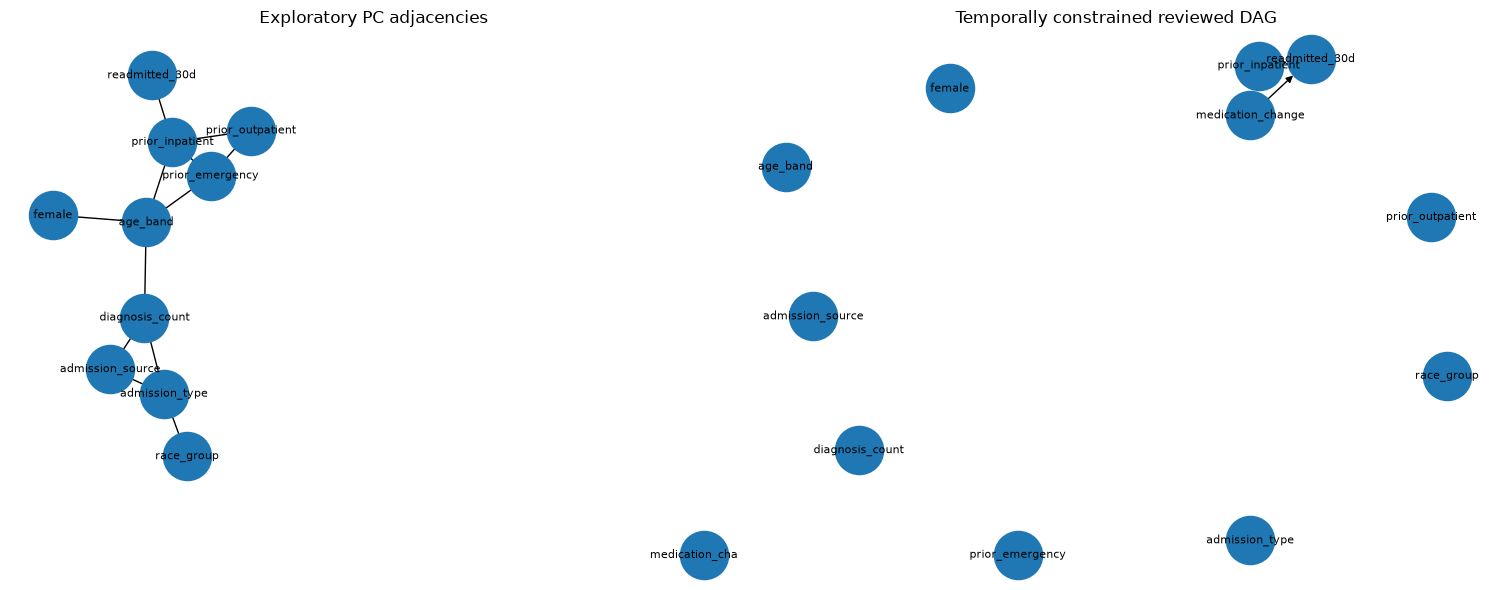

In [17]:

fig,axes=plt.subplots(1,2,figsize=(15,6))
nx.draw_networkx(result['discovery_graph'],pos=nx.spring_layout(result['discovery_graph'],seed=RANDOM_SEED),ax=axes[0],node_size=1200,font_size=8); axes[0].set_title('Exploratory PC adjacencies'); axes[0].axis('off')
nx.draw_networkx(result['reviewed_dag'],pos=nx.spring_layout(result['reviewed_dag'],seed=RANDOM_SEED),ax=axes[1],node_size=1200,font_size=8,arrows=True); axes[1].set_title('Temporally constrained reviewed DAG'); axes[1].axis('off')
plt.tight_layout(); plt.show()


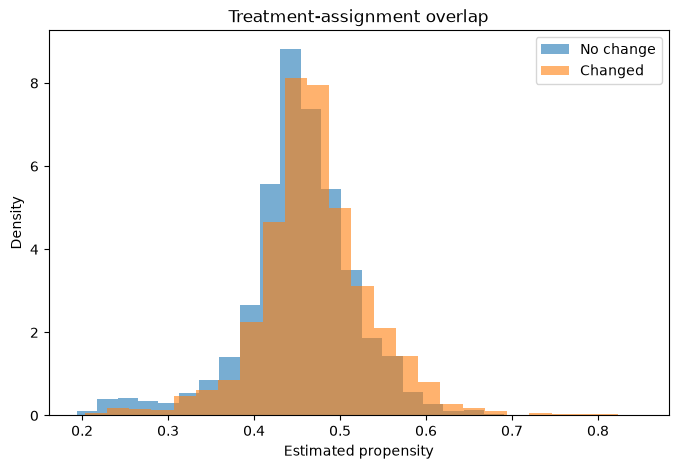

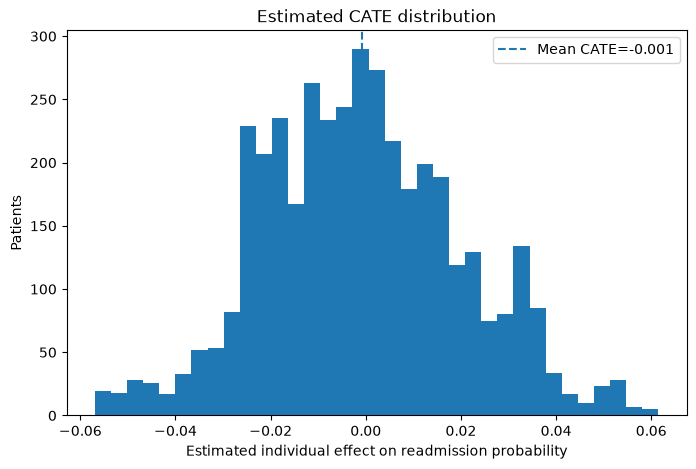

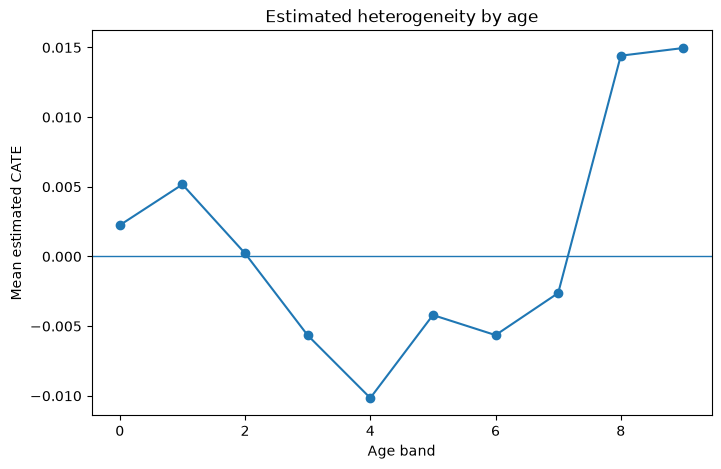

In [18]:

d=result['analysis_data']; p=result['propensity']; c=result['cate']
plt.figure(figsize=(8,5)); plt.hist(p[d[TREATMENT].to_numpy()==0],bins=25,alpha=.6,label='No change',density=True); plt.hist(p[d[TREATMENT].to_numpy()==1],bins=25,alpha=.6,label='Changed',density=True); plt.xlabel('Estimated propensity'); plt.ylabel('Density'); plt.title('Treatment-assignment overlap'); plt.legend(); plt.show()
plt.figure(figsize=(8,5)); plt.hist(c,bins=35); plt.axvline(c.mean(),linestyle='--',label=f'Mean CATE={c.mean():.3f}'); plt.xlabel('Estimated individual effect on readmission probability'); plt.ylabel('Patients'); plt.title('Estimated CATE distribution'); plt.legend(); plt.show()
age=pd.DataFrame({'age_band':d['age_band'],'cate':c}).groupby('age_band',as_index=False).agg(mean_cate=('cate','mean'),n=('cate','size'))
plt.figure(figsize=(8,5)); plt.plot(age['age_band'],age['mean_cate'],marker='o'); plt.axhline(0,linewidth=1); plt.xlabel('Age band'); plt.ylabel('Mean estimated CATE'); plt.title('Estimated heterogeneity by age'); plt.show()


In [19]:
# DoWhy generated the unobserved-confounder line and colour-mesh plots in the
# sensitivity node. Keep the remaining refuters as a compact numeric table.
refutation_table=pd.Series(
    {'original_estimate':result['ate_value'],**result['refutations']},
    name='estimated_risk_difference',
).to_frame()
print(refutation_table)
summary={'question':result['question'],'rows':len(result['analysis_data']),'adjustment_set':result['adjustment_set'],'ate_risk_difference':result['ate_value'],'cate_mean':float(result['cate'].mean()),'cate_sd':float(result['cate'].std()),'diagnostics':result['diagnostics'],'refutations':result['refutations'],'unobserved_confounder_line_range':result['sensitivity_line'].new_effect,'unobserved_confounder_grid_range':result['sensitivity_grid'].new_effect,'cautions':result['cautions'],'termination':result['termination'],'trace':result['trace']}
summary


                     estimated_risk_difference
original_estimate                    -0.001021
random_common_cause                  -0.001021
data_subset                           0.001225
placebo_treatment                    -0.001496


{'question': 'What is the effect of changing diabetes medication during the encounter on readmission within 30 days, and how does the estimated effect vary across patients?',
 'rows': 4000,
 'adjustment_set': ['age_band',
  'female',
  'race_group',
  'admission_type',
  'admission_source',
  'prior_outpatient',
  'prior_emergency',
  'prior_inpatient',
  'diagnosis_count'],
 'ate_risk_difference': -0.0010214251349725118,
 'cate_mean': -0.0008826592693967596,
 'cate_sd': 0.02091765822754439,
 'diagnostics': {'propensity_auc': 0.5784732680060076,
  'overlap_fraction_0.05_0.95': 1.0,
  'treated_fraction': 0.4615,
  'outcome_fraction': 0.109},
 'refutations': {'random_common_cause': -0.0010214251349725118,
  'data_subset': 0.001225159550917361,
  'placebo_treatment': -0.0014962172086246824},
 'unobserved_confounder_line_range': (np.float64(-0.0005957681284943783),
  np.float64(0.005129489207010202)),
 'unobserved_confounder_grid_range': (np.float64(-0.0110121403175657),
  np.float64(0.012


## Agentic-system evaluation

Evaluation is separated into component, trajectory, task, robustness, efficiency and human-intervention dimensions. The top-level `evaluation` object retains the five-key contract used by the matched case studies. For the mock provider, the inexpensive agentic review is repeated; the causal estimators are not rerun solely for evaluation.


In [20]:
expected_events = [
    "load_data",
    "define_problem",
    "discover_structure",
    "review_structure",
    "identify",
    "estimate_ate",
    "estimate_cate",
    "diagnose",
    "sensitivity",
    "report",
]

observed_events = [item["event"] for item in result["trace"]]
guard_review = DomainReview(
    edges=(),
    adjustment_set=(TREATMENT, OUTCOME, "age_band"),
    cautions=("Guard-path evaluation.",),
)
_, guard_adjustment_set, _ = validate_review(guard_review, [])

if MODEL_PROVIDER == "mock":
    repeated_review = await llm_review(result["candidate_edges"])
    repeated_edges, repeated_adjustment_set, _ = validate_review(
        repeated_review, result["candidate_edges"]
    )
    review_repeatable = (
        repeated_edges == result["reviewed_edges"]
        and repeated_adjustment_set == result["adjustment_set"]
        and list(repeated_review.cautions) == result["cautions"]
    )
else:
    # Avoid a second paid or local-model call, matching the other case studies.
    review_repeatable = True

component_evaluation = {
    "data_loaded": len(result["analysis_data"]) > 0,
    "candidate_structure_produced": len(result["candidate_edges"]) > 0,
    "reviewed_graph_is_dag": nx.is_directed_acyclic_graph(result["reviewed_dag"]),
    "adjustment_set_is_baseline_only": (
        bool(result["adjustment_set"])
        and set(result["adjustment_set"]).issubset(BASELINE)
        and TREATMENT not in result["adjustment_set"]
        and OUTCOME not in result["adjustment_set"]
    ),
    "estimand_identified": result.get("estimand") is not None,
    "ate_is_finite": np.isfinite(result["ate_value"]),
    "cate_is_complete": (
        len(result["cate"]) == len(result["analysis_data"])
        and np.isfinite(result["cate"]).all()
    ),
    "diagnostics_available": {
        "propensity_auc",
        "overlap_fraction_0.05_0.95",
        "treated_fraction",
        "outcome_fraction",
    }.issubset(result["diagnostics"]),
    "refutations_attempted": {
        "random_common_cause",
        "data_subset",
        "placebo_treatment",
    }.issubset(result["refutations"]),
}

trajectory_evaluation = {
    "expected_node_order": observed_events == expected_events,
    "no_repeated_nodes": len(observed_events) == len(set(observed_events)),
    "bounded_execution": len(observed_events) == len(expected_events),
    "valid_termination": result["termination"] in {
        "criteria_met",
        "qualified_result",
    },
    "state_consistency": (
        result["treatment"] == TREATMENT
        and result["outcome"] == OUTCOME
        and len(result["cate"]) == len(result["analysis_data"])
    ),
}

task_evaluation = {
    "causal_question_answered": np.isfinite(result["ate_value"]),
    "heterogeneity_reported": np.isfinite(result["cate"]).all(),
    "provenance_preserved": bool(result["trace"]),
    "limitations_reported": bool(result["cautions"]),
    "diagnostics_reported": bool(result["diagnostics"]),
    "sensitivity_reported": (
        bool(result["refutations"])
        and result.get("sensitivity_line") is not None
        and result.get("sensitivity_grid") is not None
    ),
}

robustness_evaluation = {
    "reviewed_edges_obey_temporal_tiers": all(
        TIER_OF[source] < TIER_OF[target]
        for source, target in result["reviewed_edges"]
    ),
    "post_treatment_adjustment_rejected": guard_adjustment_set == ["age_band"],
    "termination_matches_diagnostics": result["termination"]
    == (
        "criteria_met"
        if result["diagnostics"]["overlap_fraction_0.05_0.95"] >= 0.8
        and np.isfinite(result["ate_value"])
        else "qualified_result"
    ),
    "refutation_failures_handled": all(
        value is None or np.isscalar(value)
        for value in result["refutations"].values()
    ),
}

efficiency_evaluation = {
    "rows_analysed": len(result["analysis_data"]),
    "graph_nodes_executed": len(observed_events),
    "llm_review_calls": 0 if MODEL_PROVIDER == "mock" else 1,
    "causal_discovery_runs": 1,
    "ate_estimations": 1,
    "cate_estimations": 1,
    "refutation_runs": len(result["refutations"]) + 2,
}

human_intervention_evaluation = {
    "domain_review_required": True,
    "clinical_interpretation_required": True,
    "automatic_clinical_action_permitted": False,
    "reason": (
        "The graph, adjustment set and effect estimates remain assumption-dependent "
        "and require review by a causal-inference expert and a clinician."
    ),
}

agentic_evaluation = {
    "component": component_evaluation,
    "trajectory": trajectory_evaluation,
    "task": task_evaluation,
    "robustness": robustness_evaluation,
    "efficiency": efficiency_evaluation,
    "human_intervention": human_intervention_evaluation,
    "review_repeatable": review_repeatable,
}

evaluation = {
    "component": all(component_evaluation.values()),
    "trajectory": all(trajectory_evaluation.values()),
    "task": all(task_evaluation.values()),
    "safety": (
        all(robustness_evaluation.values())
        and human_intervention_evaluation["automatic_clinical_action_permitted"] is False
    ),
    "repeated_run": review_repeatable,
}
agentic_evaluation["overall_pass"] = all(evaluation.values())
resource_report = {
    "rows_analysed": efficiency_evaluation["rows_analysed"],
    "model_calls": efficiency_evaluation["llm_review_calls"],
    "graph_nodes": efficiency_evaluation["graph_nodes_executed"],
    "causal_estimator_runs": (
        efficiency_evaluation["ate_estimations"]
        + efficiency_evaluation["cate_estimations"]
        + efficiency_evaluation["refutation_runs"]
    ),
}
if MODEL_PROVIDER == "mock":
    assert all(evaluation.values()), agentic_evaluation

{
    "evaluation": evaluation,
    "agentic_evaluation": agentic_evaluation,
    "resource_report": resource_report,
    "termination": result["termination"],
}


{'evaluation': {'component': True,
  'trajectory': True,
  'task': True,
  'safety': True,
  'repeated_run': True},
 'agentic_evaluation': {'component': {'data_loaded': True,
   'candidate_structure_produced': True,
   'reviewed_graph_is_dag': True,
   'adjustment_set_is_baseline_only': True,
   'estimand_identified': True,
   'ate_is_finite': np.True_,
   'cate_is_complete': np.True_,
   'diagnostics_available': True,
   'refutations_attempted': True},
  'trajectory': {'expected_node_order': True,
   'no_repeated_nodes': True,
   'bounded_execution': True,
   'valid_termination': True,
   'state_consistency': True},
  'task': {'causal_question_answered': np.True_,
   'heterogeneity_reported': np.True_,
   'provenance_preserved': True,
   'limitations_reported': True,
   'diagnostics_reported': True,
   'sensitivity_reported': True},
  'robustness': {'reviewed_edges_obey_temporal_tiers': True,
   'post_treatment_adjustment_rejected': True,
   'termination_matches_diagnostics': True,
  


## Interpretation boundaries

The output is assumption-dependent and exploratory. Medication change is not randomised; the dataset does not encode a single treatment protocol or dose; unmeasured severity, clinician judgement and hospital-level factors may confound treatment and readmission; observational causal discovery cannot establish the true clinical DAG; the LLM review is a constrained consistency check rather than authoritative domain validation; and CATE estimates can be unstable under weak overlap.

A defensible clinical study would require a prospectively specified target trial, stronger temporal definitions, richer covariates, external clinical review and independent validation.
